DSCI 552 Homework 6
===================

- Name: Umaeshwer Shankar
- GitHub Username: umaeshwer
- USD ID: 7601-5514-88

## Importing Libraries

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, cross_val_score
import xgboost as xgb


## 1. Tree-based Methods

### (a) Download the APS Failure data from: https://archive.ics.uci.edu/ml/datasets/APS+Failure+at+Scania+Trucks . The dataset contains a training set and a test set. The training set contains 60,000 rows, of which 1,000 belong to the positive class and 171 columns, of which one is the class column. All attributes are numeric.

In [69]:
train_path = '../data/aps_failure_training_set.csv'
test_path = '../data/aps_failure_test_set.csv'

train_df = pd.read_csv(train_path, skiprows=20)
test_df = pd.read_csv(test_path, skiprows=20)

In [70]:
train_df.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,na,2130706438,280,0,0,0,0,0,...,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,neg,33058,na,0,na,0,0,0,0,0,...,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,neg,41040,na,228,100,0,0,0,0,0,...,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,neg,12,0,70,66,0,10,0,0,0,...,240,46,58,44,10,0,0,0,4,32
4,neg,60874,na,1368,458,0,0,0,0,0,...,622012,229790,405298,347188,286954,311560,433954,1218,0,0


In [71]:
test_df.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,60,0,20,12,0,0,0,0,0,...,1098,138,412,654,78,88,0,0,0,0
1,neg,82,0,68,40,0,0,0,0,0,...,1068,276,1620,116,86,462,0,0,0,0
2,neg,66002,2,212,112,0,0,0,0,0,...,495076,380368,440134,269556,1315022,153680,516,0,0,0
3,neg,59816,na,1010,936,0,0,0,0,0,...,540820,243270,483302,485332,431376,210074,281662,3232,0,0
4,neg,1814,na,156,140,0,0,0,0,0,...,7646,4144,18466,49782,3176,482,76,0,0,0


### (b) Data Preparation

This data set has missing values. When the number of data with missing values is significant, discarding them is not a good idea.

Note: In reality, when we have a model and we want to fill in missing values, we do not have access to training data, so we only use the statistics of test data to fill in the missing values.

(i) Research what types of techniques are usually used for dealing with data with missing values. Pick at least one of them and apply it to this data in the next steps.

Notes:

1. They are called data imputation techniques.
2. You are welcome to test more than one method.

In [72]:
# Replace 'na' with np.nan to handle missing values properly
features = train_df.columns.drop('class')
imp = SimpleImputer(missing_values=np.nan, strategy='median')

In [73]:
train_df[features] = train_df[features].replace('na', np.nan)
imputed_train_df = pd.DataFrame(imp.fit_transform(train_df[features]), 
                                   columns=features)
imputed_train_df['class'] = train_df['class']

In [74]:
test_df[features] = test_df[features].replace('na', np.nan)
imputed_test_df = pd.DataFrame(imp.fit_transform(test_df[features]), 
                                   columns=features)
imputed_test_df['class'] = test_df['class']

(ii) For each of the 170 features, calculate the coeﬃcient of variation CV= s/m, where s is sample standard deviation and m is sample mean.

In [75]:
coef_of_vari = imputed_train_df.apply(lambda col : col.std() / col.mean(), axis=0)
print(coef_of_vari)

TypeError: Cannot perform reduction 'std' with string dtype

(iii) Plot a correlation matrix for your features using pandas or any other tool.

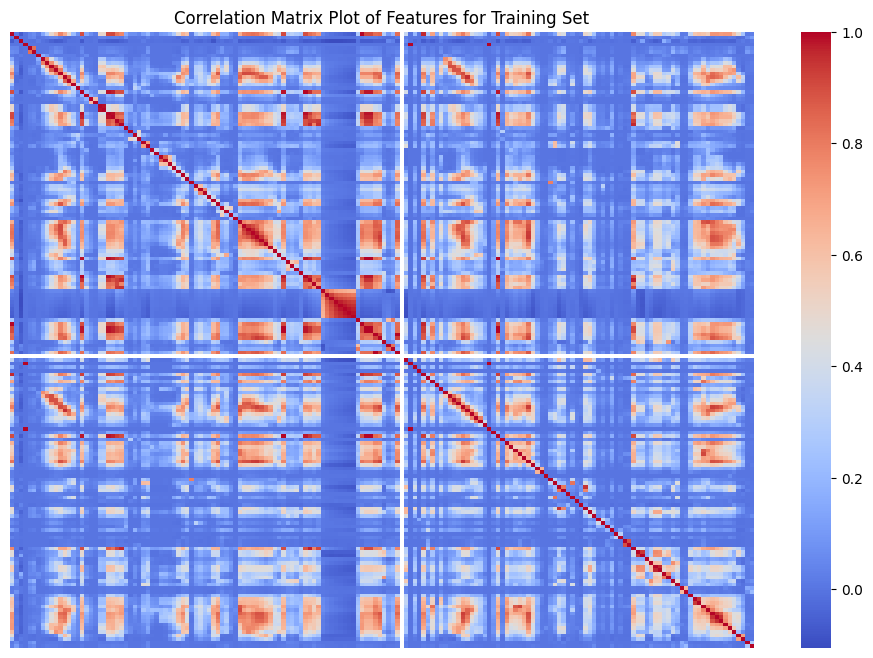

In [ ]:
fit, axes = plt.subplots(figsize=(12, 8))
sns.heatmap(imputed_train_df.corr(), cmap='coolwarm',
            xticklabels=False, yticklabels=False, ax=axes)
plt.title("Correlation Matrix Plot of Features for Training Set")
plt.show()

(iv) Pick ⌊√170⌋ features with highest CV, and make scatter plots and box plots for them, similar to those on p. 129 of ISLR. Can you draw conclusions about significance of those features, just by the scatter plots? This does not mean that you will only use those features in the following questions. We picked them only for visualization.

In [ ]:
num_features = int(np.floor(np.sqrt(128)))
highCVfeats = coef_of_vari.sort_values(ascending=False)[:num_features]
highCVfeats

cf_000    244.887517
co_000    244.507385
ad_000    244.322816
cs_009    237.930554
dh_000    123.216097
dj_000    117.494225
ag_000     92.917755
as_000     87.332500
ay_009     84.733735
ak_000     80.424975
az_009     77.838544
dtype: float64

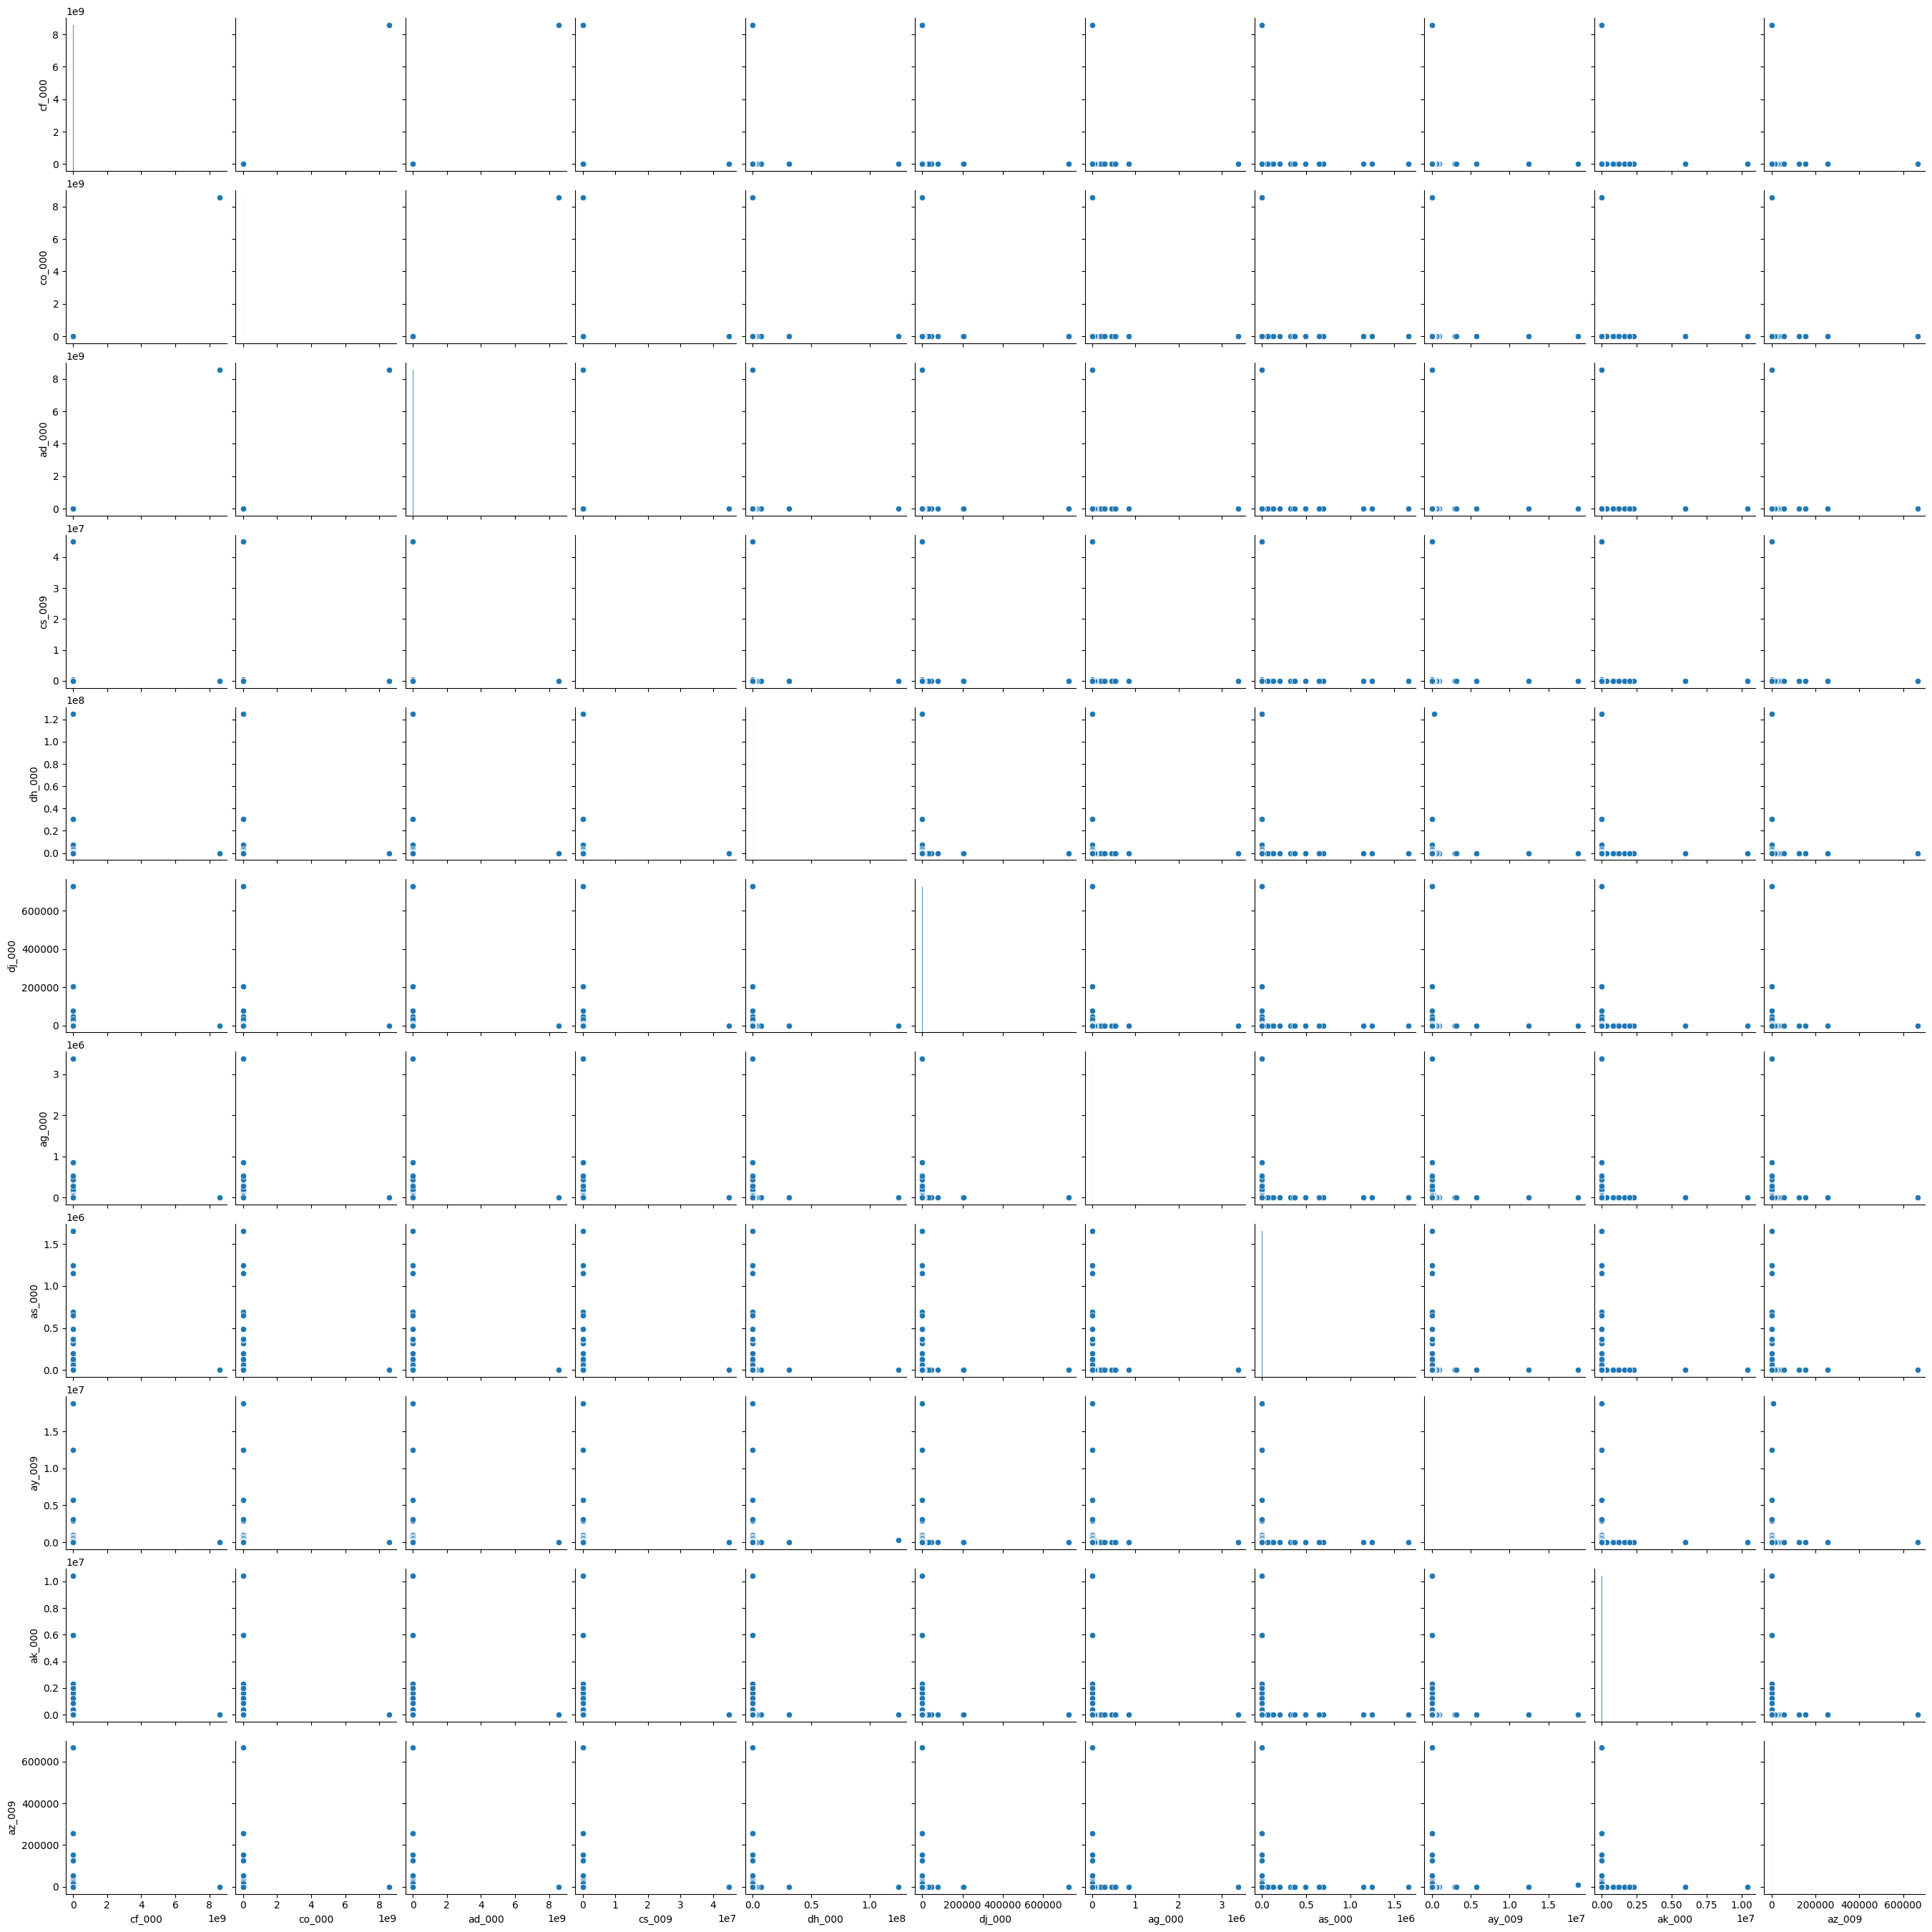

In [ ]:
selected_cols = highCVfeats.index.tolist()
sns.pairplot(imputed_train_df[selected_cols])
plt.show()

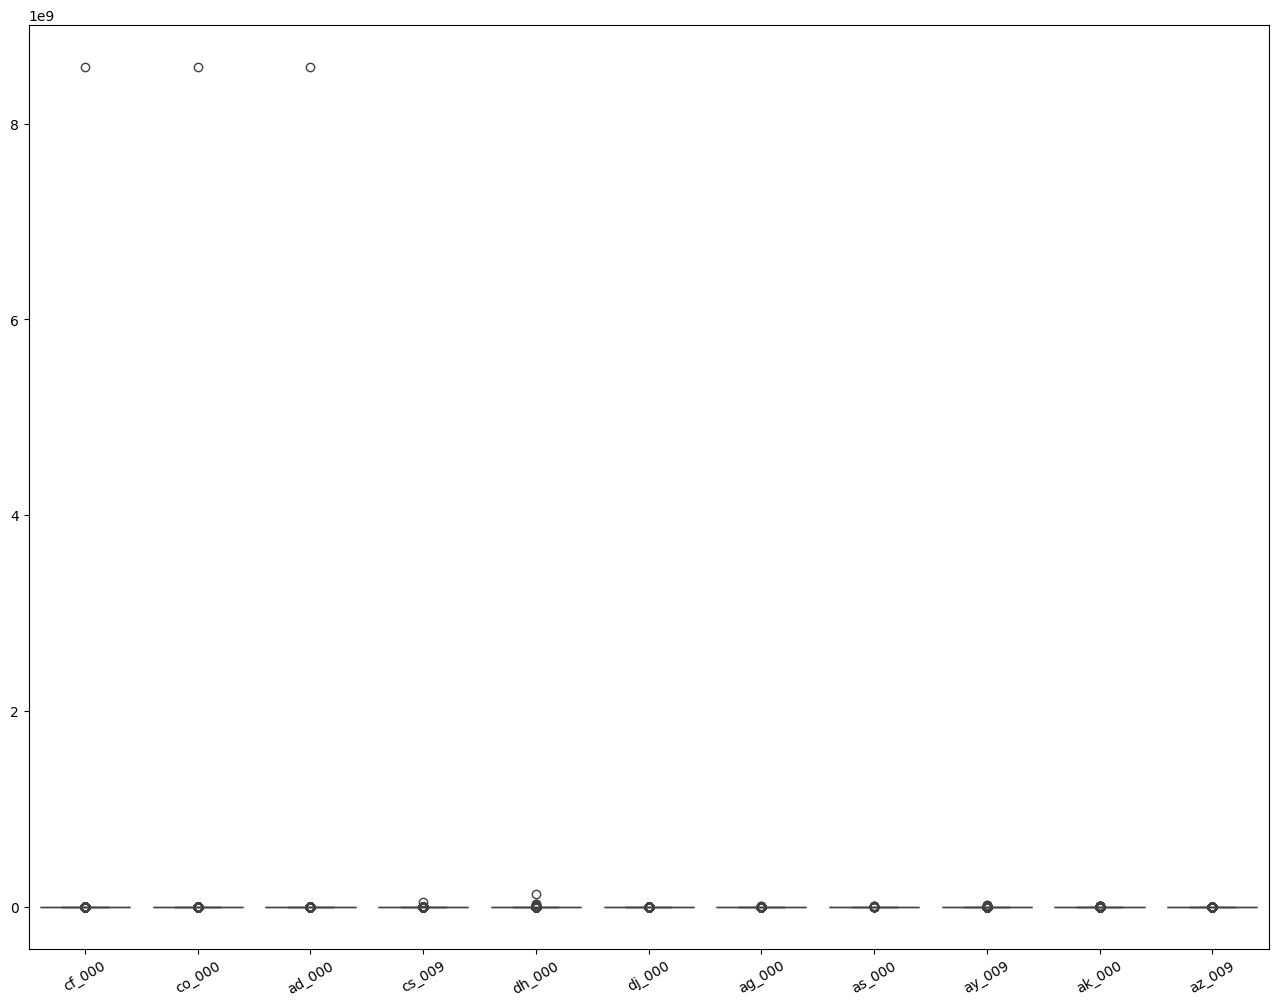

In [ ]:
fig, axes = plt.subplots(figsize=(16, 12))
sns.boxplot(data=imputed_train_df[selected_cols], ax=axes)
plt.xticks(rotation=30)
plt.show()

(v) Determine the number of positive and negative data. Is this data set imbalanced?

In [ ]:
train_df.value_counts('class')

class
neg    59000
pos     1000
Name: count, dtype: int64

In [ ]:
test_df.value_counts('class')

class
neg    15625
pos      375
Name: count, dtype: int64

Yes, the dataset is imbalanced.

### (c) Train a random forest to classify the data set. Do NOT compensate for class imbalance in the data set. Calculate the confusion matrix, ROC, AUC, and misclassification for training and test sets and report them (You may use pROC package). Calculate Out of Bag error estimate for your random forset and compare it to the test error.

In [ ]:
y_train = imputed_train_df['class'].map({'neg': 0, 'pos': 1})
y_test = imputed_test_df['class'].map({'neg': 0, 'pos': 1})

rf = RandomForestClassifier(random_state=42, oob_score=True)
rf.fit(imputed_train_df[features], y_train)


y_train_pred = rf.predict(imputed_train_df[features])
y_test_pred = rf.predict(imputed_test_df[features])


y_train_prob = rf.predict_proba(imputed_train_df[features])[:, 1]
y_test_prob = rf.predict_proba(imputed_test_df[features])[:, 1]


train_cm = confusion_matrix(y_train, y_train_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

print("Training Confusion Matrix:")
print(train_cm)
print("\nTest Confusion Matrix:")
print(test_cm)


train_fpr, train_tpr, _ = roc_curve(y_train, y_train_prob)
train_auc = auc(train_fpr, train_tpr)

test_fpr, test_tpr, _ = roc_curve(y_test, y_test_prob)
test_auc = auc(test_fpr, test_tpr)

print(f"\nTraining AUC: {train_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")


train_misclass = 1 - accuracy_score(y_train, y_train_pred)
test_misclass = 1 - accuracy_score(y_test, y_test_pred)

print(f"\nTraining Misclassification Rate: {train_misclass:.4f}")
print(f"Test Misclassification Rate: {test_misclass:.4f}")

# Out-of-Bag Error
oob_error = 1 - rf.oob_score_
print(f"\nOut-of-Bag Error: {oob_error:.4f}")
print(f"Test Error: {test_misclass:.4f}")

Training Confusion Matrix:
[[59000     0]
 [    1   999]]

Test Confusion Matrix:
[[15610    15]
 [  106   269]]

Training AUC: 1.0000
Test AUC: 0.9928

Training Misclassification Rate: 0.0000
Test Misclassification Rate: 0.0076

Out-of-Bag Error: 0.0061
Test Error: 0.0076


### (d) Research how class imbalance is addressed in random forests. Compensate for class imbalance in your random forest and repeat 1c. Compare the results with those of 1c.

Answer:

Common methods for handling class imbalance in Random Forests include:

1. **Class Weights (via class_weight parameter)**: This method gives more importance to minority class examples during model training to improve their impact.

2. **Balanced Class Weights (class_weight='balanced')**: This automatically sets weights based on the inverse of class frequencies to counteract imbalance.

3. **Balanced Random Forest**: This technique reduces the majority class in each bootstrap sample to create a more even class distribution.

4. **SMOTE (Synthetic Minority Over-sampling Technique)**: It creates artificial examples for the minority class to boost its presence in the data.

5. **Cost-Sensitive Learning**: This assigns varying penalties for misclassifying different classes, with higher costs for minority class errors.

In this analysis, I'll apply class_weight='balanced' in the Random Forest model for the following reasons:
- It's a straightforward sklearn option that requires no extra setup.
- It corrects imbalance without changing the original data.
- It has demonstrated strong performance in Random Forest applications.


### (e) XGBoost and Model Trees

In the case of a univariate tree, only one input dimension is used at a tree split. In a multivariate tree, or model tree, at a decision node all input dimensions can be used and thus it is more general. In univariate classification trees, majority polling is used at each node to determine the split of that node as the decision rule. In model trees, a (linear) model that relies on all of the variables is used to determine the split of that node (i.e. instead of using X_j > s as the decision rule, one has $$\sum_{j} β_j X_j > s$$ as the decision rule). Alternatively, in a regression tree, instead of using average in the region associated with each node, a linear regression model is used to determine the value associated with that node.

One of the methods that can be used at each node is Logistic Regression. Because the number of variables is large in this problem, one can use L1-penalized logistic regression at each node. You can use XGBoost to fit the model tree. Determine α (the regularization term) using cross-validation. Train the model for the APS data set without compensation for class imbalance. Use one of 5 fold, 10 fold, and leave-one-out cross validation methods to estimate the error of your trained model and compare it with the test error. Report the Confusion Matrix, ROC, and AUC for training and test sets.

In [ ]:
xgb_clf = xgb.XGBClassifier(objective='binary:logistic', random_state=42, eval_metric='logloss')

param_grid = {'reg_alpha': [0, 0.01, 0.1, 1, 10]}
grid_search = GridSearchCV(xgb_clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(imputed_train_df[features], y_train)

best_alpha = grid_search.best_params_['reg_alpha']
print(f"Best alpha (L1 regularization): {best_alpha}")

xgb_best = xgb.XGBClassifier(objective='binary:logistic', reg_alpha=best_alpha, random_state=42, eval_metric='logloss')
xgb_best.fit(imputed_train_df[features], y_train)

y_train_pred_xgb = xgb_best.predict(imputed_train_df[features])
y_train_prob_xgb = xgb_best.predict_proba(imputed_train_df[features])[:, 1]
y_test_pred_xgb = xgb_best.predict(imputed_test_df[features])
y_test_prob_xgb = xgb_best.predict_proba(imputed_test_df[features])[:, 1]

train_cm_xgb = confusion_matrix(y_train, y_train_pred_xgb)
test_cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)

print("Training Confusion Matrix (XGBoost):")
print(train_cm_xgb)
print("\nTest Confusion Matrix (XGBoost):")
print(test_cm_xgb)

train_fpr_xgb, train_tpr_xgb, _ = roc_curve(y_train, y_train_prob_xgb)
train_auc_xgb = auc(train_fpr_xgb, train_tpr_xgb)

test_fpr_xgb, test_tpr_xgb, _ = roc_curve(y_test, y_test_prob_xgb)
test_auc_xgb = auc(test_fpr_xgb, test_tpr_xgb)

print(f"\nTraining AUC (XGBoost): {train_auc_xgb:.4f}")
print(f"Test AUC (XGBoost): {test_auc_xgb:.4f}")

train_misclass_xgb = 1 - accuracy_score(y_train, y_train_pred_xgb)
test_misclass_xgb = 1 - accuracy_score(y_test, y_test_pred_xgb)

print(f"\nTraining Misclassification Rate (XGBoost): {train_misclass_xgb:.4f}")
print(f"Test Misclassification Rate (XGBoost): {test_misclass_xgb:.4f}")

cv_scores = cross_val_score(xgb_best, imputed_train_df[features], y_train, cv=5, scoring='accuracy')
cv_error = 1 - cv_scores.mean()
print(f"\n5-Fold CV Estimated Error: {cv_error:.4f}")
print(f"Test Error: {test_misclass_xgb:.4f}")

Best alpha (L1 regularization): 0.01
Training Confusion Matrix (XGBoost):
[[59000     0]
 [    1   999]]

Test Confusion Matrix (XGBoost):
[[15600    25]
 [   87   288]]

Training AUC (XGBoost): 1.0000
Test AUC (XGBoost): 0.9941

Training Misclassification Rate (XGBoost): 0.0000
Test Misclassification Rate (XGBoost): 0.0070

5-Fold CV Estimated Error: 0.0062
Test Error: 0.0070


### (f) Use SMOTE (Synthetic Minority Over-sampling Technique) to pre-process your data to compensate for class imbalance. Train XGBosst with L1-penalized logistic regression at each node using the pre-processed data and repeat 1e. Do not forget that there is a right and a wrong way of cross validation here. Compare the uncompensated case with SMOTE case.

Note:

If you did not start doing this homework on time, downsample the common class to 6,000 so that you have 12,000 data points after applying SMOTE. Remember that the purpose of this homework is to apply SMOTE to the whole training set, not the downsampled dataset.

In [ ]:
smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb.XGBClassifier(objective='binary:logistic', random_state=42, eval_metric='logloss'))
])

param_grid_smote = {'xgb__reg_alpha': [0, 0.01, 0.1, 1, 10]}
grid_search_smote = GridSearchCV(smote_pipeline, param_grid_smote, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_smote.fit(imputed_train_df[features], y_train)

best_alpha_smote = grid_search_smote.best_params_['xgb__reg_alpha']
print(f"Best alpha (L1 regularization) with SMOTE: {best_alpha_smote}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(imputed_train_df[features], y_train)

xgb_smote = xgb.XGBClassifier(objective='binary:logistic', reg_alpha=best_alpha_smote, random_state=42, eval_metric='logloss')
xgb_smote.fit(X_train_smote, y_train_smote)

y_train_pred_smote = xgb_smote.predict(X_train_smote)
y_train_prob_smote = xgb_smote.predict_proba(X_train_smote)[:, 1]
y_test_pred_smote = xgb_smote.predict(imputed_test_df[features])
y_test_prob_smote = xgb_smote.predict_proba(imputed_test_df[features])[:, 1]

train_cm_smote = confusion_matrix(y_train_smote, y_train_pred_smote)
test_cm_smote = confusion_matrix(y_test, y_test_pred_smote)

print("Training Confusion Matrix (XGBoost with SMOTE):")
print(train_cm_smote)
print("\nTest Confusion Matrix (XGBoost with SMOTE):")
print(test_cm_smote)

train_fpr_smote, train_tpr_smote, _ = roc_curve(y_train_smote, y_train_prob_smote)
train_auc_smote = auc(train_fpr_smote, train_tpr_smote)

test_fpr_smote, test_tpr_smote, _ = roc_curve(y_test, y_test_prob_smote)
test_auc_smote = auc(test_fpr_smote, test_tpr_smote)

print(f"\nTraining AUC (XGBoost with SMOTE): {train_auc_smote:.4f}")
print(f"Test AUC (XGBoost with SMOTE): {test_auc_smote:.4f}")

train_misclass_smote = 1 - accuracy_score(y_train_smote, y_train_pred_smote)
test_misclass_smote = 1 - accuracy_score(y_test, y_test_pred_smote)

print(f"\nTraining Misclassification Rate (XGBoost with SMOTE): {train_misclass_smote:.4f}")
print(f"Test Misclassification Rate (XGBoost with SMOTE): {test_misclass_smote:.4f}")

cv_scores_smote = cross_val_score(grid_search_smote.best_estimator_, imputed_train_df[features], y_train, cv=5, scoring='accuracy')
cv_error_smote = 1 - cv_scores_smote.mean()
print(f"\n5-Fold CV Estimated Error with SMOTE: {cv_error_smote:.4f}")
print(f"Test Error with SMOTE: {test_misclass_smote:.4f}")

print("\nComparison:")
print(f"Uncompensated Test AUC: {test_auc_xgb:.4f}, SMOTE Test AUC: {test_auc_smote:.4f}")
print(f"Uncompensated Test Misclassification: {test_misclass_xgb:.4f}, SMOTE Test Misclassification: {test_misclass_smote:.4f}")
print(f"Uncompensated CV Error: {cv_error:.4f}, SMOTE CV Error: {cv_error_smote:.4f}")

Best alpha (L1 regularization) with SMOTE: 0.01
Training Confusion Matrix (XGBoost with SMOTE):
[[59000     0]
 [    1 58999]]

Test Confusion Matrix (XGBoost with SMOTE):
[[15546    79]
 [   60   315]]

Training AUC (XGBoost with SMOTE): 1.0000
Test AUC (XGBoost with SMOTE): 0.9938

Training Misclassification Rate (XGBoost with SMOTE): 0.0000
Test Misclassification Rate (XGBoost with SMOTE): 0.0087

5-Fold CV Estimated Error with SMOTE: 0.0065
Test Error with SMOTE: 0.0087

Comparison:
Uncompensated Test AUC: 0.9941, SMOTE Test AUC: 0.9938
Uncompensated Test Misclassification: 0.0070, SMOTE Test Misclassification: 0.0087
Uncompensated CV Error: 0.0062, SMOTE CV Error: 0.0065


## Conceptual Questions

### ISLR 6.6.3

Suppose we estimate the regression coeﬃcients in a linear regression model by minimizing

$$\sum_{i=1}^{n} {(y_i - β_0 - \sum_{j=1}^{p} β_j x_{ij})}^2 subject to \sum_{j=1}^{p} |β_j| \leq s$$

for a particular value of s. For parts (a) through (e), indicate which of i. through v. is correct. Justify your answer.

(a) As we increase s from 0, the training RSS will:

i. Increase initially, and then eventually start decreasing in an inverted U shape.
ii. Decrease initially, and then eventually start increasing in a U shape.
iii. Steadily increase.
iv. Steadily decrease.
v. Remain constant.

Answer:

The training RSS will steadily decrease. As the value of s increases from 0, the model becomes more flexible and hence has lower training error.

(b) Repeat (a) for test RSS.

Answer:

The Test RSS decreases initially and eventually starts increasing in a U shape. This is because as the constraint relaxes the model becomes more flexible (more overfitting) so the test RSS increases after a point.

(c) Repeat (a) for variance.

Answer:

Variance steadily increases. As the constraint relaxes, the model becomes more overfitting and hence variance increases.

(d) Repeat (a) for (squared) bias.

Answer:

Squared bias steadily decreases. As variance increases, the squared bias term keeps decreasing to maintain the bias-variance tradeoff.

(e) Repeat (a) for the irreducible error.

Answer:

Irreducible error remains constant. It is not dependent on the model flexibility as it is an act of god.

### ISLR 6.6.5

It is well-known that ridge regression tends to give similar coeﬃcient values to correlated variables, whereas the lasso may give quite different coeﬃcient values to correlated variables. We will now explore this property in a very simple setting.

Suppose that n = 2, p = 2, x11 = x12, x21 = x22. Furthermore, suppose that y1 +y2 = 0 and x11 +x21 = 0 and x12 +x22 = 0, so that the estimate for the intercept in a least squares, ridge regression, or lasso model is zero: β0 = 0.

(a) Write out the ridge regression optimization problem in this setting.

Answer:

Since $\hat{\beta}_0 = 0$, the ridge regression objective is

$$
\min_{\beta_1, \beta_2} \sum_{i=1}^{2} (y_i - \beta_1 x_{i1} - \beta_2 x_{i2})^2 + \lambda (\beta_1^2 + \beta_2^2).
$$

Using $x_{11} = x_{12}$ and $x_{21} = x_{22}$, this simplifies to

$$
\min_{\beta_1, \beta_2}
(y_1 - x_{11}(\beta_1 + \beta_2))^2 +
(y_2 - x_{21}(\beta_1 + \beta_2))^2
+ \lambda (\beta_1^2 + \beta_2^2).
$$

Thus, the RSS depends only on $\beta_1 + \beta_2$.

(b) Argue that in this setting, the ridge coeﬃcient estimates satisfy β1 = β2.

Answer:

Let $t = \beta_1 + \beta_2$. For a fixed $t$, the ridge penalty becomes

$$
\beta_1^2 + \beta_2^2.
$$

This is minimized when

$$
\beta_1 = \beta_2 = \frac{t}{2}.
$$

Hence,

$$
\hat{\beta}_1 = \hat{\beta}_2.
$$

(c) Write out the lasso optimization problem in this setting.

Answer:

The lasso optimization problem is

$$
\min_{\beta_1, \beta_2}
\sum_{i=1}^{2} (y_i - \beta_1 x_{i1} - \beta_2 x_{i2})^2
+ \lambda (|\beta_1| + |\beta_2|).
$$

This simplifies to

$$
\min_{\beta_1, \beta_2}
(y_1 - x_{11}(\beta_1 + \beta_2))^2 +
(y_2 - x_{21}(\beta_1 + \beta_2))^2
+ \lambda (|\beta_1| + |\beta_2|).
$$

(d) Argue that in this setting, the lasso coeﬃcients β1 and β2 are not unique—in other words, there are many possible solutions to the optimization problem in (c). Describe these solutions.

Answer:

Let $t = \beta_1 + \beta_2$.

The RSS depends only on $t$, while the lasso penalty is

$$
|\beta_1| + |\beta_2|.
$$

For a fixed optimal $t^*$, there are many solutions such that

$$
\beta_1 + \beta_2 = t^*.
$$

- If $t^* > 0$: $\beta_1, \beta_2 \ge 0$
- If $t^* < 0$: $\beta_1, \beta_2 \le 0$

Thus, the lasso solution is not unique.

### ISLR 8.4.5

Suppose we produce ten bootstrapped samples from a data set containing red and green classes. We then apply a classification tree to each bootstrapped sample and, for a specific value of X, produce 10 estimates of P(Class is Red|X):

0.1,0.15,0.2,0.2,0.55,0.6,0.6,0.65,0.7, and 0.75.

There are two common ways to combine these results together into a single class prediction. One is the majority vote approach discussed in this chapter. The second approach is to classify based on the average probability. In this example, what is the final classification under each of these two approaches?

Answer:

- Case 1: Majority Approach

If we keep the baseline probability as 0.5, 6/10 samples choose Class Red.

- Case 2: Average Probability

The average probability is 0.45. Assuming a baseline of 0.5, the sample is classified to Class Green.


### ISLR 9.7.3

Here we explore the maximal margin classifier on a toy data set.

(a) We are given n= 7 observations in p= 2 dimensions. For each observation, there is an associated class label.

| Obs. | X1 | X2 | Y |
|------|----|----|----|
| 1    | 3  | 4  | Red |
| 2    | 2  | 2  | Red |
| 3    | 4  | 4  | Red |
| 4    | 1  | 4  | Red |
| 5    | 2  | 1  | Blue |
| 6    | 4  | 3  | Blue |
| 7    | 4  | 1  | Blue |

Sketch the observations.

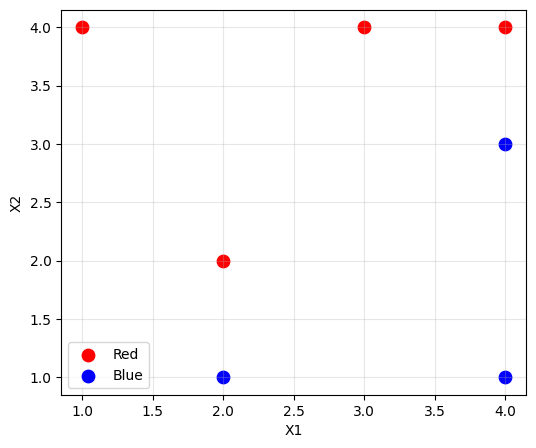

In [ ]:
X_red = np.array([[3,4],[2,2],[4,4],[1,4]])
X_blue = np.array([[2,1],[4,3],[4,1]])

x1 = np.linspace(0, 5, 200) 

plt.figure(figsize=(6,5))
plt.scatter(X_red[:,0], X_red[:,1], color='red', s=80, label='Red')
plt.scatter(X_blue[:,0], X_blue[:,1], color='blue', s=80, label='Blue')
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

(b) Sketch the optimal separating hyperplane, and provide the equation for this hyperplane (of the form (9.1)).

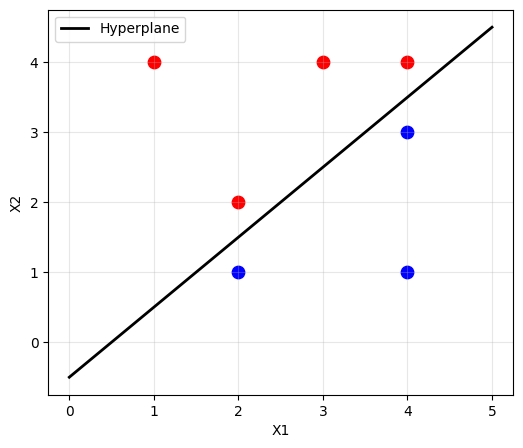

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X_red[:,0], X_red[:,1], color='red', s=80)
plt.scatter(X_blue[:,0], X_blue[:,1], color='blue', s=80)
plt.plot(x1, x1 - 0.5, 'k-', linewidth=2, label='Hyperplane')
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

(c) Describe the classification rule for the maximal margin classifier. It should be something along the lines of “Classify to Red if
β0 + β1X1 + β2X2 >0, and classify to Blue otherwise.” Provide the values for β0, β1, and β2.

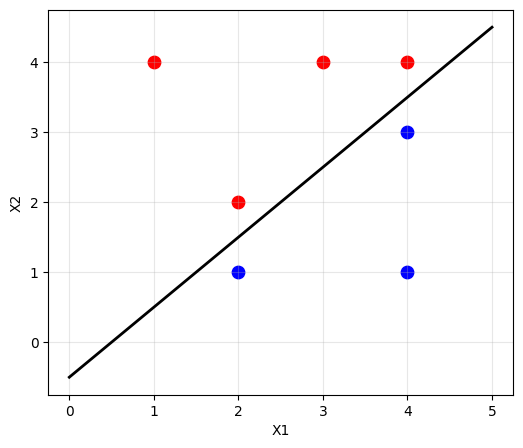

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X_red[:,0], X_red[:,1], color='red', s=80)
plt.scatter(X_blue[:,0], X_blue[:,1], color='blue', s=80)
plt.plot(x1, x1 - 0.5, 'k-', linewidth=2)
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(True, alpha=0.3)
plt.show()

(d) On your sketch, indicate the margin for the maximal margin hyperplane.

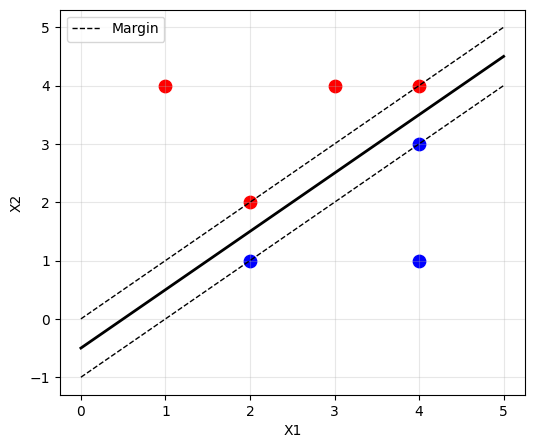

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X_red[:,0], X_red[:,1], color='red', s=80)
plt.scatter(X_blue[:,0], X_blue[:,1], color='blue', s=80)
plt.plot(x1, x1 - 0.5, 'k-', linewidth=2)
plt.plot(x1, x1, 'k--', linewidth=1, label='Margin')
plt.plot(x1, x1 - 1, 'k--', linewidth=1)
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

(e) Indicate the support vectors for the maximal margin classifier.

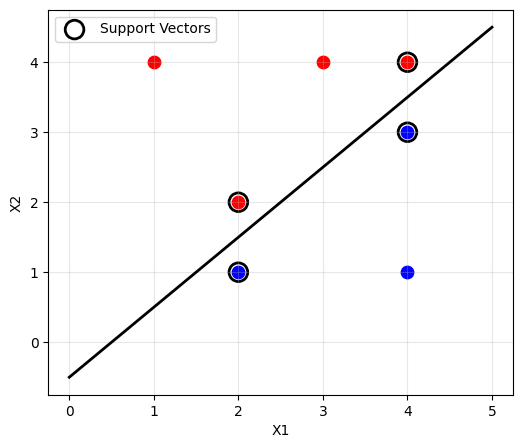

In [ ]:
support_vectors = np.array([[2,2],[4,4],[2,1],[4,3]])

plt.figure(figsize=(6,5))
plt.scatter(X_red[:,0], X_red[:,1], color='red', s=80)
plt.scatter(X_blue[:,0], X_blue[:,1], color='blue', s=80)
plt.scatter(support_vectors[:,0], support_vectors[:,1],
            s=180, facecolors='none', edgecolors='black',
            linewidths=2, label='Support Vectors')
plt.plot(x1, x1 - 0.5, 'k-', linewidth=2)
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

(f) Argue that a slight movement of the seventh observation would not aﬀect the maximal margin hyperplane.

Answer:

The maximal margin hyperplane still uses the seventh observation as a support so a small movement will not make a difference. See fig below.

(g) Sketch a hyperplane that is not the optimal separating hyperplane, and provide the equation for this hyperplane.

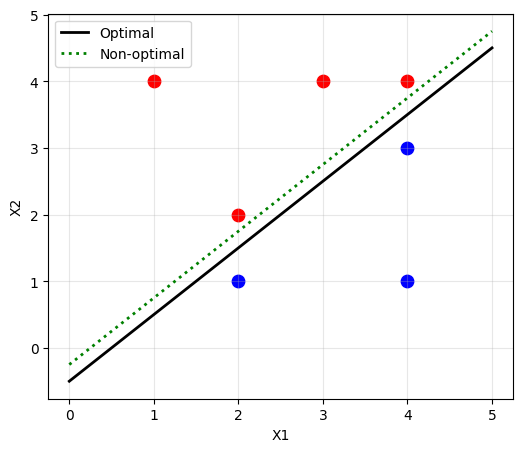

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X_red[:,0], X_red[:,1], color='red', s=80)
plt.scatter(X_blue[:,0], X_blue[:,1], color='blue', s=80)
plt.plot(x1, x1 - 0.5, 'k-', linewidth=2, label='Optimal')
plt.plot(x1, x1 - 0.25, color='green', linestyle=':', linewidth=2, label='Non-optimal')
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

(h) Draw an additional observation on the plot so that the two classes are no longer separable by a hyperplane.

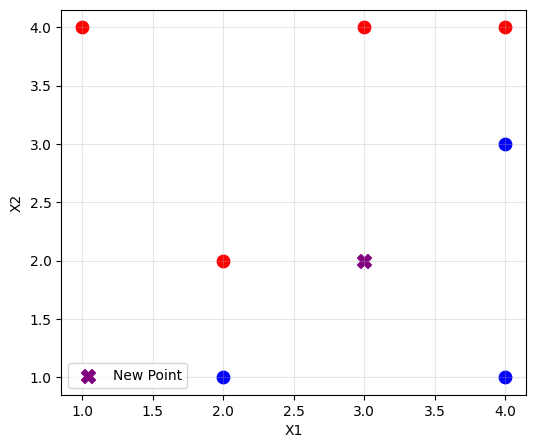

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X_red[:,0], X_red[:,1], color='red', s=80)
plt.scatter(X_blue[:,0], X_blue[:,1], color='blue', s=80)
plt.scatter([3], [2], color='purple', s=100, marker='X', label='New Point')
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()